In [1]:
import torch
from config import ConfigGPT
from tokenizer import Tokenizer
from gpt import GPT

import numpy as np
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

C:\PythonProjects\python_beginners_course-main\ML_Workshop\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
with open('alice.txt', 'r', encoding='utf-8') as f:
    text = f.read()

print("Character count:", len(text))
encoder = Tokenizer()
text = encoder.train(text, num_merges=50) # mild compression (small dataset + simple model will not work well with immense tokens merging)
print("Total number of tokens:", len(text))

config = ConfigGPT(vocab_size=encoder.vocab_size)

assert  (config.num_heads * config.head_size == config.num_embed), 'Num heads mismatch'

Character count: 144016


Merging tokens: 100%|██████████| 50/50 [00:01<00:00, 28.86it/s]

Total number of tokens: 98082


In [3]:
def create_xy(config):
    x = []
    y = []

    context_window = [0] * config.context_length
    for i in range(len(text) - 1):
        context_window = context_window[1:] + [text[i]]
        target_window = context_window[1:] + [text[i + 1]]
        x.append(context_window)
        y.append(target_window)
    return x, y

In [4]:
x, y = create_xy(config)
n = int(0.9 * len(text))
x_train, y_train = x[:n], y[:n]
x_val, y_val = x[n:], y[n:]

print(len(x_train))
print(len(y_train))
print(len(x_val))
print(len(y_val))

print(len(x_val) / len(x)) # kinda sanity check

88273
88273
9808
9808
0.0999989804345388


In [5]:
def get_batch(config, split):
    x = x_train if split == 'train' else x_val
    y = y_train if split == 'train' else y_val
    x_batch = []
    y_batch = []
    for _ in range(config.batch_size):
        idx = np.random.randint(low=0, high=len(x))
        x_b, y_b = x[idx], y[idx]
        x_batch.append(x_b)
        y_batch.append(y_b)

    x_batch = torch.tensor(x_batch, dtype=torch.long).to(config.device)
    y_batch = torch.tensor(y_batch, dtype=torch.long).to(config.device)

    return x_batch, y_batch

x_batch, y_batch = get_batch(config, 'train')
print(x_batch.shape, x_batch.dtype)

torch.Size([32, 64]) torch.int64


In [6]:
print(f"X=")
print(x_batch[0].tolist())
print()
print(f"Y=")
print(y_batch[0].tolist())

X=
[295, 42, 295, 295, 295, 42, 295, 295, 295, 42, 276, 10, 268, 87, 281, 116, 302, 99, 117, 114, 105, 265, 274, 102, 101, 101, 108, 273, 33, 269, 266, 292, 264, 304, 101, 59, 32, 268, 73, 32, 109, 117, 115, 262, 98, 256, 115, 104, 117, 116, 116, 300, 117, 112, 32, 278, 107, 256, 97, 10, 116, 101, 108, 296]

Y=
[42, 295, 295, 295, 42, 295, 295, 295, 42, 276, 10, 268, 87, 281, 116, 302, 99, 117, 114, 105, 265, 274, 102, 101, 101, 108, 273, 33, 269, 266, 292, 264, 304, 101, 59, 32, 268, 73, 32, 109, 117, 115, 262, 98, 256, 115, 104, 117, 116, 116, 300, 117, 112, 32, 278, 107, 256, 97, 10, 116, 101, 108, 296, 99]


## Training the baseline GPT model

In [7]:
gpt = GPT(config)
optimizer = torch.optim.Adam(params=gpt.parameters(), lr=3e-2)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=200)

In [8]:
trainable_params = sum(p.numel() for p in gpt.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params:,}")

Trainable parameters: 20,770


In [9]:
def autocomplete(start_phrase, num_tokens=100):
    enc_phrase = encoder.encode(start_phrase)
    enc_phrase = torch.tensor(enc_phrase).unsqueeze(0)
    return encoder.decode(gpt.generate(enc_phrase, num_tokens)[0].tolist())

print("GPT (Untrained) generation:\n----")
result = autocomplete("Hello,", 100)
print(result)

GPT (Untrained) generation:
----
&$ �ӖK�!{��~ the �c�erq��_&O�4��Bing�at ths( s��d li��-e &ofc�[<������t�FyouD�s �her&���t


In [10]:
train_losses = []
val_losses = []

total_steps = 500
loop = tqdm(range(total_steps), total=total_steps, desc='Training GPT Model')
for step in loop:
    # Train
    gpt.train()
    x_batch, y_batch = get_batch(config, 'train')
    _, loss = gpt(x_batch, y_batch)
    train_losses.append(loss.item())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Evaluate
    gpt.eval()
    with torch.no_grad():
        x_batch, y_batch = get_batch(config, 'val')
        _, loss = gpt(x_batch, y_batch)
        val_losses.append(loss.item())

    scheduler.step()

    loop.set_postfix(loss=f'{loss.item():.4f}')

Training GPT Model: 100%|██████████| 500/500 [00:25<00:00, 19.59it/s, loss=3.0623]


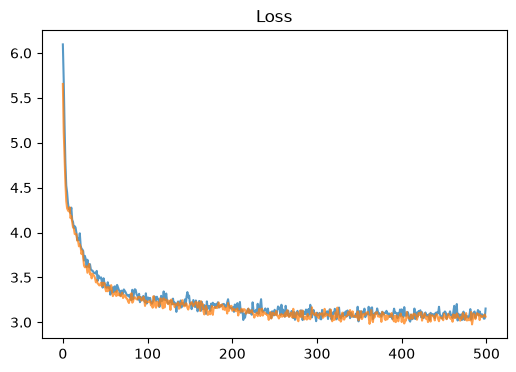

In [11]:
plt.figure(figsize=(6, 4))
plt.plot(train_losses, label='Train', alpha=0.75)
plt.plot(val_losses, label='Val', alpha=0.75)
plt.title("Loss");

In [12]:
torch.save(gpt.state_dict(), 'gpt_params_base.pth')

In [13]:
print("GPT (Base model, trained) generation:\n----")
result = autocomplete("Hello,", 500)
print(result)

GPT (Base model, trained) generation:
----
Hello, atled the bigle rise; the jure fureftea ““Sth angecus seced was tot s?”

“I wer r herewed udlots mougand be ther be; and nghre ther
Pit saiding-f inn ep ay
fured enteen a woce fan’fet she Groo,
thered inucouly wend sat. ve; nod
alik d the Mall thit icat saboust tharumt nedgh its yoube, veren har ctach af.

“I mice, onetleakpenter.

“N “Now.” sit w.

“Pigiriroury wimy (_you jrepimif mextodeds n’ttly ne. _ Doth _y wandoustlly and win the d tooomid tot ic?”

“He ghucre, andrform-fotlanockner the—f.

Tld wougabrte want’s nownle inkelot, she nas and to lester hone her shave ther, and—” the for,
bout e _f: wouly.”

“Whon!

“Nachat jat
d to arely ee, “havery cainting hoy of ming, andd the der forch
any s


## Training on a bigger text file (Twitter conversations) with a larger architecture

In [14]:
with open('TwitterConvCorpus.txt', 'r', encoding='utf-8') as f:
    text = f.read()

print("Character count:", len(text))
encoder = Tokenizer()
text = encoder.train(text, num_merges=0)
print("Total number of tokens:", len(text))

Character count: 598556
Total number of tokens: 612338


The hyperparameters configuration is kind of arbitrary, the goal was to simply scale this thing up and see what happens. 

In [15]:
config = ConfigGPT(
    vocab_size=encoder.vocab_size,
    context_length=32,
    num_layers=3,
    num_embed=256,
    head_size=32,
    num_heads=8
)

assert  (config.num_heads * config.head_size == config.num_embed), 'Num heads mismatch'

In [16]:
x, y = create_xy(config)
n = int(0.9 * len(text))
x_train, y_train = x[:n], y[:n]
x_val, y_val = x[n:], y[n:]

print(len(x_train))
print(len(y_train))
print(len(x_val))
print(len(y_val))

551104
551104
61233
61233


In [17]:
gpt = GPT(config)
optimizer = torch.optim.Adam(params=gpt.parameters(), lr=3e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=200)

In [18]:
trainable_params = sum(p.numel() for p in gpt.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params:,}")

Trainable parameters: 2,505,728


In [19]:
train_losses = []
val_losses = []

total_steps = 1400
loop = tqdm(range(total_steps), total=total_steps, desc='Training GPT Model')
for step in loop:
    # Train
    gpt.train()
    x_batch, y_batch = get_batch(config, 'train')
    _, loss = gpt(x_batch, y_batch)
    train_losses.append(loss.item())
    optimizer.zero_grad()
    
    loss.backward()
    optimizer.step()

    # Evaluate
    gpt.eval()
    with torch.no_grad():
        x_batch, y_batch = get_batch(config, 'val')
        _, loss = gpt(x_batch, y_batch)
        val_losses.append(loss.item())

    scheduler.step()

    loop.set_postfix(loss=f'{loss.item():.4f}')

Training GPT Model: 100%|██████████| 1400/1400 [05:37<00:00,  4.15it/s, loss=2.0493]


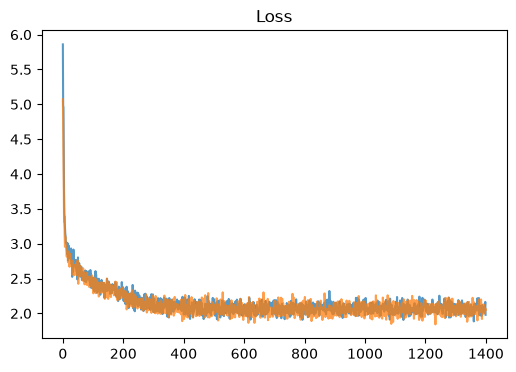

In [20]:
plt.figure(figsize=(6, 4))
plt.plot(train_losses, label='Train', alpha=0.75)
plt.plot(val_losses, label='Val', alpha=0.75)
plt.title("Loss");

In [21]:
torch.save(gpt.state_dict(), 'gpt_params_main.pth')

In [22]:
print("GPT (Main model, trained) generation:\n----")
result = autocomplete("Hello,", 1000)
print(result)

GPT (Main model, trained) generation:
----
Hello, them a worked irres to clay.




gart allit
wull she stard, here the dabh with nee brome. I canstes lettely my antryced,....way read that seall like a go play...
Buthing gring ?



stan I'm sambre beett nat to camcout like difeeting I durst buese came)🙌🏽
colle just ask lol
they stad
dan't have ouldnestrycheep it
wird "tood at's frigle, your liking match keem cackoooke I lol not thit it's out well I cone and that hange. I whe more my gare your.!! Lech chen out plespice kianc.
gett sturtic if on in think Inke, not the can't wasnt say goive sting maning DilpOons of puckiong questo of He with in stacks a was like whel up work you are anded shouse difdring prop seeps
trat starthemoraheynive! Drke tume lottuce clike gote??
No, usen ⬰️.
lest I'm allike tee brigg. Piver it mand thot lisle neek I alcrly is astlion as.



I say get though as.
got is would a my but voeccal, al liker moule. I cond to knich. p of the your ever lost a jomers.
din't m